 PHASE 3: THE SELF-ASCRIPTION CHECK

[1] RAW FREQUENCIES (N)
valence      Mixed  Negative  Neutral  Positive
perspective                                    
Auto           120       113      136        79
Hetero          27        48       13         3

[2] PERCENTAGES (%)
valence       Mixed Negative Neutral Positive
perspective                                  
Auto         26.79%   25.22%  30.36%   17.63%
Hetero       29.67%   52.75%  14.29%     3.3%

[3] CHI-SQUARE TEST RESULTS
 - Chi-Square Statistic: 36.7006
 - p-value: 5.3239e-08
 RESULT: Statistically Significant. Perspective heavily influences valence!

✅ Final plot saved as 'perspective_analysis.png'


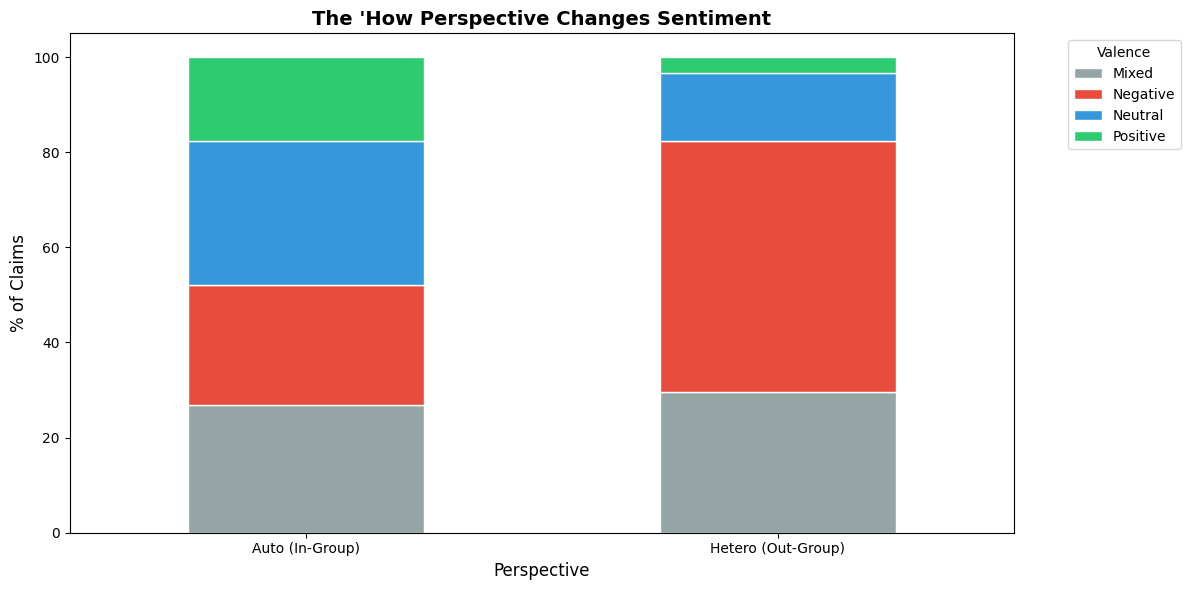

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv('/kaggle/input/notebooks/ianaaa/chat-gpt-annotating/generational_stereotypes_full_run.csv')

# 1. Filter for clear Auto vs Hetero perspectives
stede_df = df[df['perspective'].isin(['Auto', 'Hetero'])].copy()

# 2. STATISTICAL REPORT: PERSPECTIVE VS VALENCE
print("="*60)
print(" PHASE 3: THE SELF-ASCRIPTION CHECK")
print("="*60)

# Frequencies
ct_val = pd.crosstab(stede_df['perspective'], stede_df['valence'])
print("\n[1] RAW FREQUENCIES (N)")
print(ct_val)

# Percentages
ct_val_perc = pd.crosstab(stede_df['perspective'], stede_df['valence'], normalize='index') * 100
print("\n[2] PERCENTAGES (%)")
print(ct_val_perc.round(2).astype(str) + '%')

# Chi-Square Test
chi2, p, dof, ex = chi2_contingency(ct_val)
print("\n[3] CHI-SQUARE TEST RESULTS")
print(f" - Chi-Square Statistic: {chi2:.4f}")
print(f" - p-value: {p:.4e}")
if p < 0.05:
    print(" RESULT: Statistically Significant. Perspective heavily influences valence!")

# 3. VISUALIZATION: The "In-Group" Favoritism Plot
plt.figure(figsize=(12, 6))

val_colors = {'Negative': '#e74c3c', 'Positive': '#2ecc71', 'Neutral': '#3498db', 'Mixed': '#95a5a6'}

ct_val_perc.plot(kind='bar', stacked=True, color=[val_colors[c] for c in ct_val_perc.columns], ax=plt.gca(), edgecolor='white')

plt.title("The 'How Perspective Changes Sentiment", fontsize=14, fontweight='bold')
plt.ylabel("% of Claims", fontsize=12)
plt.xlabel("Perspective", fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Auto (In-Group)', 'Hetero (Out-Group)'], rotation=0)
plt.legend(title="Valence", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('perspective_analysis.png')
print("\n✅ Final plot saved as 'perspective_analysis.png'")